In [1]:
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import seaborn as sns
k_list = [5,16 ,32 ,64 ,80 ,96 ,128 ,160 ,200 ,240 ,280 ,320 ,340 ,400]
import re
from scipy import stats
import numpy as np
def extract_scores(text):
    # Extracting the required scores from the text with a very flexible comet score pattern
    results = {}

    # Splitting the text based on the dynamic path pattern
    path_pattern = r'/raid/lyu/.*?score:'
    split_text = re.split(path_pattern, text)
    if len(split_text) < 2:
        return "No valid path or score data found in the text."

    json_data_part = split_text[0].strip()
    scores_part = 'score:' + split_text[1].strip()

    # Extracting JSON data for BLEU and chrF2
    try:
        json_data = eval(json_data_part)
        for data in json_data:
            if data["name"] in ["BLEU", "chrF2"]:
                results[data["name"]] = data["score"]
    except:
        return "Error in parsing JSON data."

    # Extracting scores from the scores part with a very flexible pattern for comet score
    comet_score = re.search(r'score:\s*([0-9.]+)', scores_part)
    entity_accuracy = re.search(r'Total Accuracy:\s*([0-9.]+)', scores_part)
    bertscore_f1 = re.search(r'bert.*F1:\s*([0-9.]+)', scores_part)
    bleurt_score = re.search(r'([0-9.]+)\s*$', scores_part)

    if comet_score:
        results["comet"] = float(comet_score.group(1))
    if entity_accuracy:
        results["entity Accuracy"] = float(entity_accuracy.group(1))
    if bertscore_f1:
        results["bertscore F1"] = float(bertscore_f1.group(1))
    if bleurt_score:
        results["BLEURT"] = float(bleurt_score.group(1))

    return results


In [2]:
#en-ru low resource
path_prefix="/raid/lyu/QEBT/test_dev/test_en2ru_low/"
ref_file="/raid/lyu/en-ru/tests/generaltest2023.en-ru.ref.refA.ru"

In [3]:
#read data
bs_model_score = {}
bs_mbr_score = {}
bs_qe_score = {}
for k in tqdm(k_list):
    with open(path_prefix+'/bs/{}/ct2_output.hypo_{}.score'.format(k,k),"r",encoding="utf-8") as f:
        bs_model_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/mbr_bs/output_{}/mbr.score'.format(k),"r",encoding="utf-8") as f:
        tmp_list = [json.loads(line.strip()) for line in f.readlines()]
        #reshape
        bs_mbr_score[k] = []
        for i in range(len(tmp_list)):
            bs_mbr_score[k].extend(tmp_list[i])
    with open(path_prefix+'/qe_bs/output_{}/qe.output.score'.format(k),"r",encoding="utf-8") as f:
        bs_qe_score[k] = [float(line.strip()) for line in f.readlines()]
    assert len(bs_model_score[k]) == len(bs_mbr_score[k]) == len(bs_qe_score[k])
as_model_score = {}
as_mbr_score = {}
as_qe_score = {}
for k in tqdm(k_list):
    with open(path_prefix+'/as/{}/ct2_output.hypo_{}.score'.format(k,k),"r",encoding="utf-8") as f:
        as_model_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/mbr_as/output_{}/mbr.score'.format(k),"r",encoding="utf-8") as f:
        tmp_list = [json.loads(line.strip()) for line in f.readlines()]
        #reshape
        as_mbr_score[k] = []
        for i in range(len(tmp_list)):
            as_mbr_score[k].extend(tmp_list[i])
    with open(path_prefix+'/qe_as/output_{}/qe.output.score'.format(k),"r",encoding="utf-8") as f:
        as_qe_score[k] = [float(line.strip()) for line in f.readlines()]
    assert len(as_model_score[k]) == len(as_mbr_score[k]) == len(as_qe_score[k])

100%|██████████| 14/14 [00:09<00:00,  1.53it/s]


In [4]:
bs_pearsonr_mbr_modelscore = []
bs_pearsonr_qe_modelscore = []
bs_pearsonr_qe_mbrs = []
for k in tqdm(k_list,desc="calculating pearsonr",total=len(k_list)):
    bs_pearsonr_mbr_modelscore.append(stats.pearsonr(bs_mbr_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_modelscore.append(stats.pearsonr(bs_qe_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_mbrs.append(stats.pearsonr(bs_qe_score[k],bs_mbr_score[k])[0])
as_pearsonr_mbr_modelscore = []
as_pearsonr_qe_modelscore = []
as_pearsonr_qe_mbrs = []
for k in tqdm(k_list,desc="calculating pearsonr",total=len(k_list)):
    as_pearsonr_mbr_modelscore.append(stats.pearsonr(as_mbr_score[k],as_model_score[k])[0])
    as_pearsonr_qe_modelscore.append(stats.pearsonr(as_qe_score[k],as_model_score[k])[0])
    as_pearsonr_qe_mbrs.append(stats.pearsonr(as_qe_score[k],as_mbr_score[k])[0])

calculating pearsonr: 100%|██████████| 14/14 [00:04<00:00,  3.42it/s]


In [4]:
from scipy.stats import spearmanr
from scipy.stats import rankdata
from multiprocessing import Pool

# Define your existing data structures
bs_qe_rank = {}
bs_mbr_rank = {}
bs_model_rank = {}
bs_spearmanr_qe_modelscore = []
bs_spearmanr_mbr_modelscore = []
bs_spearmanr_qe_mbrs = []

as_qe_rank={}
as_mbr_rank={}
as_model_rank={}
as_spearmanr_qe_modelscore = []
as_spearmanr_mbr_modelscore = []
as_spearmanr_qe_mbrs = []

# Your existing data like bs_qe_score, bs_mbr_score, bs_model_score, and k_list should be defined here

# Define a function to handle the computation for each k
def process_k_as(k):
    qe_rank, mbr_rank, model_rank = [], [], []
    for i in range(len(bs_mbr_score[k]) // k):
        tmp_qe = as_qe_score[k][i*k:(i+1)*k]
        tmp_mbr = as_mbr_score[k][i*k:(i+1)*k]
        tmp_model = as_model_score[k][i*k:(i+1)*k]

        ranked_qe = rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe = [k+1-x for x in ranked_qe]
        ranked_mbr = rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr = [k+1-x for x in ranked_mbr]
        ranked_model = rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model = [k+1-x for x in ranked_model]

        qe_rank.extend(ranked_qe)
        mbr_rank.extend(ranked_mbr)
        model_rank.extend(ranked_model)

    return (qe_rank, mbr_rank, model_rank, 
            spearmanr(qe_rank, model_rank)[0], 
            spearmanr(mbr_rank, model_rank)[0], 
            spearmanr(qe_rank, mbr_rank)[0])
    

def process_k_bs(k):
    qe_rank, mbr_rank, model_rank = [], [], []
    for i in range(len(bs_mbr_score[k]) // k):
        tmp_qe = bs_qe_score[k][i*k:(i+1)*k]
        tmp_mbr = bs_mbr_score[k][i*k:(i+1)*k]
        tmp_model = bs_model_score[k][i*k:(i+1)*k]

        ranked_qe = rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe = [k+1-x for x in ranked_qe]
        ranked_mbr = rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr = [k+1-x for x in ranked_mbr]
        ranked_model = rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model = [k+1-x for x in ranked_model]

        qe_rank.extend(ranked_qe)
        mbr_rank.extend(ranked_mbr)
        model_rank.extend(ranked_model)

    return (qe_rank, mbr_rank, model_rank, 
            spearmanr(qe_rank, model_rank)[0], 
            spearmanr(mbr_rank, model_rank)[0], 
            spearmanr(qe_rank, mbr_rank)[0])

# Use multiprocessing to parallelize the loop
if __name__ == "__main__":
    with Pool() as pool:
        results = list(tqdm(pool.imap(process_k_bs, k_list), total=len(k_list)))

    # Unpack results and update the data structures
    for k, (qe_rank, mbr_rank, model_rank, sr_qe_model, sr_mbr_model, sr_qe_mbr) in zip(k_list, results):
        bs_qe_rank[k] = qe_rank
        bs_mbr_rank[k] = mbr_rank
        bs_model_rank[k] = model_rank
        bs_spearmanr_qe_modelscore.append(sr_qe_model)
        bs_spearmanr_mbr_modelscore.append(sr_mbr_model)
        bs_spearmanr_qe_mbrs.append(sr_qe_mbr)
    
    with Pool() as pool:
        results = list(tqdm(pool.imap(process_k_as, k_list), total=len(k_list)))
    
    for k, (qe_rank, mbr_rank, model_rank, sr_qe_model, sr_mbr_model, sr_qe_mbr) in zip(k_list, results):
        as_qe_rank[k] = qe_rank
        as_mbr_rank[k] = mbr_rank
        as_model_rank[k] = model_rank
        as_spearmanr_qe_modelscore.append(sr_qe_model)
        as_spearmanr_mbr_modelscore.append(sr_mbr_model)
        as_spearmanr_qe_mbrs.append(sr_qe_mbr)


100%|██████████| 14/14 [00:02<00:00,  5.45it/s]


In [5]:
#plt.figure(figsize=(10, 6))  # 设置画布大小
plt.plot(k_list, bs_pearsonr_mbr_modelscore, label="BS-MBR-model score", linewidth=2)
plt.plot(k_list, bs_pearsonr_qe_modelscore, label="BS-QE-model score", linewidth=2)
plt.plot(k_list, bs_pearsonr_qe_mbrs, label="BS-QE-MBR", linewidth=2,)
plt.plot(k_list, as_pearsonr_mbr_modelscore, label="AS-MBR-model score", linewidth=2, linestyle=':')
plt.plot(k_list, as_pearsonr_qe_modelscore, label="AS-QE-model score", linewidth=2, linestyle='-.')
plt.plot(k_list, as_pearsonr_qe_mbrs, label="AS-QE-MBR", linewidth=2, linestyle='--')

plt.title('Pearson correlation coefficient,En-Ru high resource')  # 添加标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('Correlation')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()




NameError: name 'bs_pearsonr_mbr_modelscore' is not defined

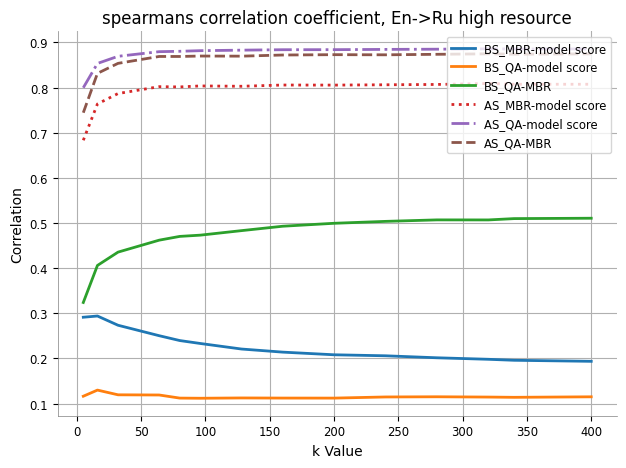

In [8]:
plt.figure()
plt.plot(k_list,bs_spearmanr_mbr_modelscore,label="BS_MBR-model score",linewidth=2)
plt.plot(k_list,bs_spearmanr_qe_modelscore,label="BS_QA-model score",linewidth=2)
plt.plot(k_list,bs_spearmanr_qe_mbrs,label="BS_QA-MBR",linewidth=2,)
plt.plot(k_list,as_spearmanr_mbr_modelscore,label="AS_MBR-model score",linewidth=2,linestyle=':')
plt.plot(k_list,as_spearmanr_qe_modelscore,label="AS_QA-model score",linewidth=2,linestyle='-.')
plt.plot(k_list,as_spearmanr_qe_mbrs,label="AS_QA-MBR",linewidth=2,linestyle='--')
plt.title('spearmans correlation coefficient, En->Ru high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('Correlation')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()

In [7]:
bs_output_text_mbr={}
bs_output_text_qe={}
bs_output_text_bs={}
bs_output_text_mbr_bleu={}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_bs/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        bs_output_text_mbr[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/qe_bs/output_{}/qe.output'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_qe[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/bs/{}/hypo_1'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_bs[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/mbr_bleu_bs/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        bs_output_text_mbr_bleu[k] = [line.strip() for line in f.readlines()]
    assert len(bs_output_text_mbr[k]) == len(bs_output_text_qe[k]) == len(bs_output_text_bs[k])==len(bs_output_text_mbr_bleu[k])
    
as_output_text_mbr={}
as_output_text_qe={}
as_output_text_bs={}
as_output_text_mbr_bleu={}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_as/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        as_output_text_mbr[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/qe_as/output_{}/qe.output'.format(k),"r",encoding="utf-8") as f:
        as_output_text_qe[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/as/{}/hypo_1'.format(k),"r",encoding="utf-8") as f:
        as_output_text_bs[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/mbr_bleu_as/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        as_output_text_mbr_bleu[k] = [line.strip() for line in f.readlines()]
    assert len(as_output_text_mbr[k]) == len(as_output_text_qe[k]) == len(as_output_text_bs[k])==len(as_output_text_mbr_bleu[k])


100%|██████████| 14/14 [00:03<00:00,  4.56it/s]


In [5]:
#统计长度分布
bs_mean_len_mbr = []
bs_mean_len_qe = []
bs_mean_len_bs = []
bs_mean_len_mbr_bleu = []
for k in k_list:
    bs_mean_len_mbr.append(np.mean([len(line.split()) for line in bs_output_text_mbr[k]]))
    bs_mean_len_qe.append(np.mean([len(line.split()) for line in bs_output_text_qe[k]]))
    bs_mean_len_bs.append(np.mean([len(line.split()) for line in bs_output_text_bs[k]]))
    bs_mean_len_mbr_bleu.append(np.mean([len(line.split()) for line in bs_output_text_mbr_bleu[k]]))
as_mean_len_mbr = []
as_mean_len_qe = []
as_mean_len_bs = []
as_mean_len_mbr_bleu = []
for k in k_list:
    as_mean_len_mbr.append(np.mean([len(line.split()) for line in as_output_text_mbr[k]]))
    as_mean_len_qe.append(np.mean([len(line.split()) for line in as_output_text_qe[k]]))
    as_mean_len_bs.append(np.mean([len(line.split()) for line in as_output_text_bs[k]]))
    as_mean_len_mbr_bleu.append(np.mean([len(line.split()) for line in as_output_text_mbr_bleu[k]]))
    
ref_len=[]   
with open(ref_file,"r",encoding="utf-8") as f:
    ref_text = [line.strip() for line in f.readlines()]
    ref_len=[len(line) for line in ref_text]
ref_mean_len = np.mean([len(line.split()) for line in ref_text])

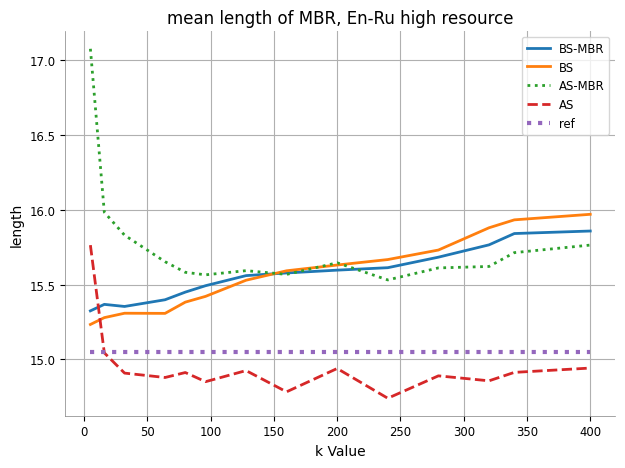

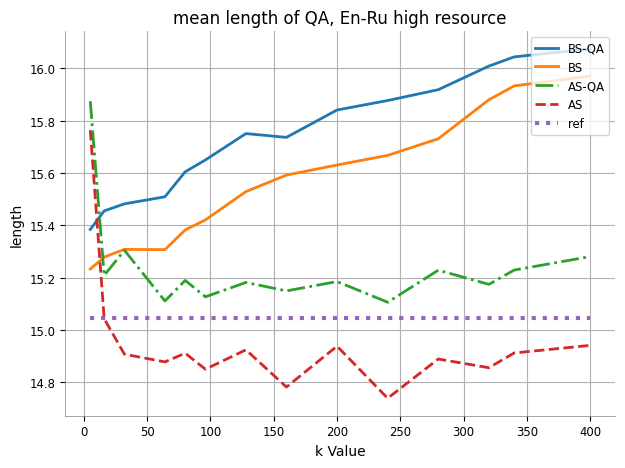

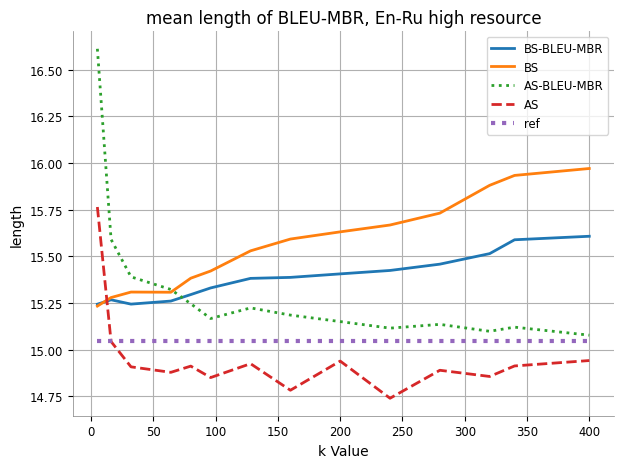

In [6]:
#画出长度分布的折线图
plt.figure()
plt.plot(k_list,bs_mean_len_mbr,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_mbr,label="AS-MBR",linewidth=2,linestyle=':')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of MBR, En-Ru high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,bs_mean_len_qe,label="BS-QA",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_qe,label="AS-QA",linewidth=2,linestyle='-.')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of QA, En-Ru high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
#再画一张mbr_bleu的图,放在旁边
plt.figure()
plt.plot(k_list,bs_mean_len_mbr_bleu,label="BS-BLEU-MBR",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_mbr_bleu,label="AS-BLEU-MBR",linewidth=2,linestyle=':')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of BLEU-MBR, En-Ru high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域
# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)



In [3]:
#提取评价指标
bs_mbr_metrics = {}
bs_qe_metrics = {}
bs_metrics = {}
bs_mbr_bleu_metrics = {}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_mbr_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/qe_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_qe_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/bs/{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/mbr_bleu_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_mbr_bleu_metrics[k] = [extract_scores(f.read())]
    assert len(bs_mbr_metrics[k]) == len(bs_qe_metrics[k]) == len(bs_metrics[k])==len(bs_mbr_bleu_metrics[k])
as_mbr_metrics = {}
as_qe_metrics = {}
as_metrics = {}
as_mbr_bleu_metrics = {}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_as/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_mbr_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/qe_as/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_qe_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/as/{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'/mbr_bleu_as/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_mbr_bleu_metrics[k] = [extract_scores(f.read())]
    assert len(as_mbr_metrics[k]) == len(as_qe_metrics[k]) == len(as_metrics[k])==len(as_mbr_bleu_metrics[k])

100%|██████████| 14/14 [00:00<00:00, 15.92it/s]


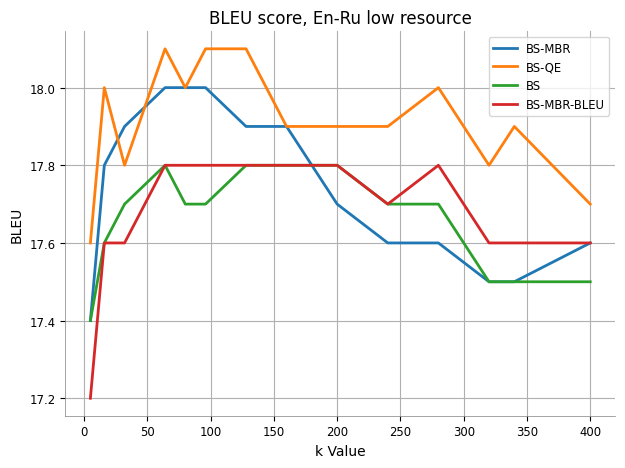

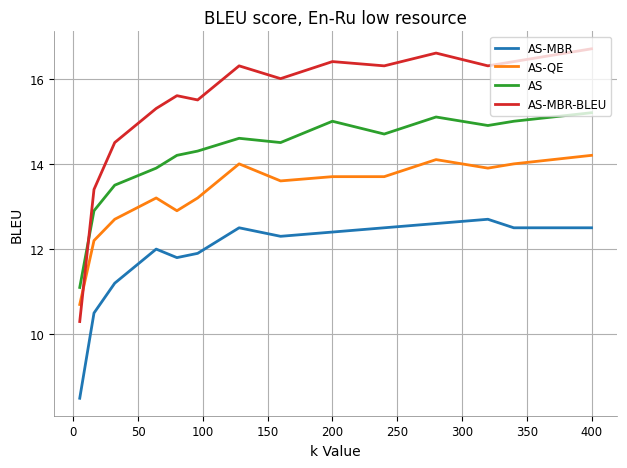

In [5]:
#BLEU
bs_mbr_bleu = []
bs_mbr_bleu_bleu = []
as_mbr_bleu = []
as_mbr_bleu_bleu = []
bs_qe_bleu = []
as_qe_bleu = []
bs_bleu = []
as_bleu = []
for k in k_list:
    bs_mbr_bleu.append(bs_mbr_metrics[k][0]["BLEU"])
    bs_qe_bleu.append(bs_qe_metrics[k][0]["BLEU"])
    bs_bleu.append(bs_metrics[k][0]["BLEU"])
    bs_mbr_bleu_bleu.append(bs_mbr_bleu_metrics[k][0]["BLEU"])
    as_mbr_bleu.append(as_mbr_metrics[k][0]["BLEU"])
    as_qe_bleu.append(as_qe_metrics[k][0]["BLEU"])
    as_bleu.append(as_metrics[k][0]["BLEU"])
    as_mbr_bleu_bleu.append(as_mbr_bleu_metrics[k][0]["BLEU"])
plt.figure()
plt.plot(k_list,bs_mbr_bleu,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_bleu,label="BS-QE",linewidth=2)
plt.plot(k_list,bs_bleu,label="BS",linewidth=2)
plt.plot(k_list,bs_mbr_bleu_bleu,label="BS-MBR-BLEU",linewidth=2)
plt.title('BLEU score, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('BLEU')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,as_mbr_bleu,label="AS-MBR",linewidth=2)
plt.plot(k_list,as_qe_bleu,label="AS-QE",linewidth=2)
plt.plot(k_list,as_bleu,label="AS",linewidth=2)
plt.plot(k_list,as_mbr_bleu_bleu,label="AS-MBR-BLEU",linewidth=2)
plt.title('BLEU score, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('BLEU')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)


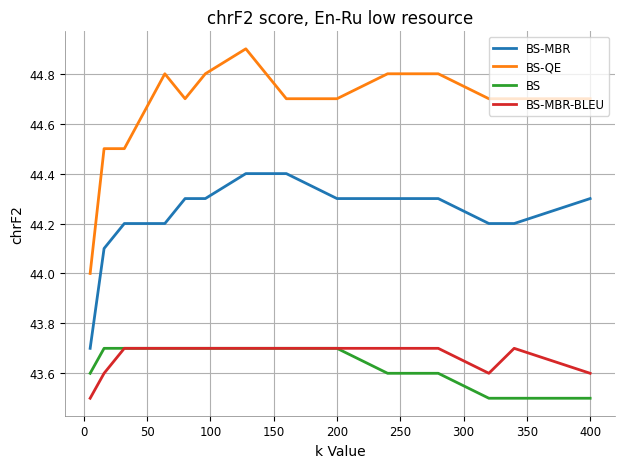

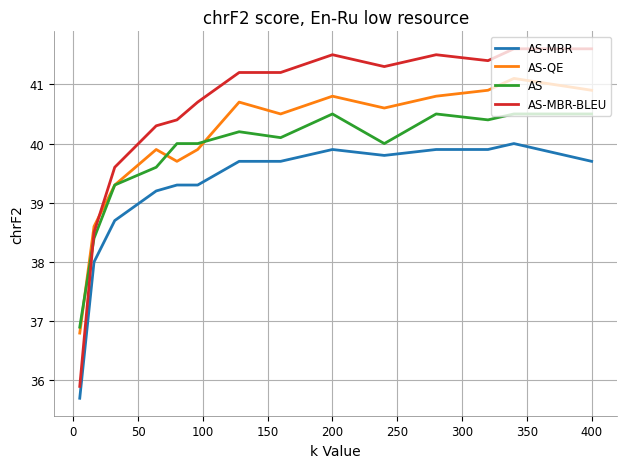

In [6]:
#chrF2
bs_mbr_chrf2 = []
bs_qe_chrf2 = []
bs_chrf2 = []
bs_mbr_chrf2_bleu = []
as_mbr_chrf2 = []
as_qe_chrf2 = []
as_chrf2 = []
as_mbr_chrf2_bleu = []
for k in k_list:
    bs_mbr_chrf2.append(bs_mbr_metrics[k][0]["chrF2"])
    bs_qe_chrf2.append(bs_qe_metrics[k][0]["chrF2"])
    bs_chrf2.append(bs_metrics[k][0]["chrF2"])
    bs_mbr_chrf2_bleu.append(bs_mbr_bleu_metrics[k][0]["chrF2"])
    as_mbr_chrf2.append(as_mbr_metrics[k][0]["chrF2"])
    as_qe_chrf2.append(as_qe_metrics[k][0]["chrF2"])
    as_chrf2.append(as_metrics[k][0]["chrF2"])
    as_mbr_chrf2_bleu.append(as_mbr_bleu_metrics[k][0]["chrF2"])
plt.figure()
plt.plot(k_list,bs_mbr_chrf2,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_chrf2,label="BS-QE",linewidth=2)
plt.plot(k_list,bs_chrf2,label="BS",linewidth=2)
plt.plot(k_list,bs_mbr_chrf2_bleu,label="BS-MBR-BLEU",linewidth=2)
plt.title('chrF2 score, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('chrF2')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,as_mbr_chrf2,label="AS-MBR",linewidth=2)
plt.plot(k_list,as_qe_chrf2,label="AS-QE",linewidth=2)
plt.plot(k_list,as_chrf2,label="AS",linewidth=2)
plt.plot(k_list,as_mbr_chrf2_bleu,label="AS-MBR-BLEU",linewidth=2)
plt.title('chrF2 score, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('chrF2')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()

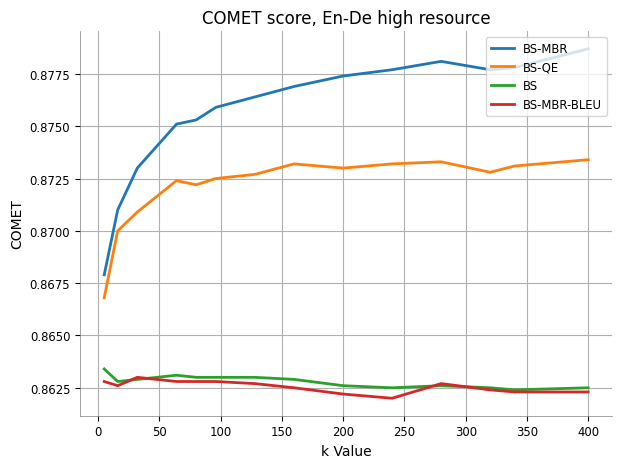

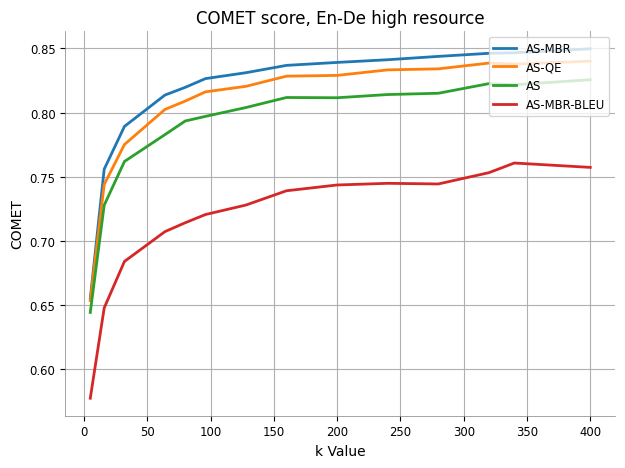

In [16]:
#comet
bs_mbr_comet = []
bs_mbr_bleu_comet = []
as_mbr_comet = []
as_mbr_bleu_comet = []
bs_qe_comet = []
as_qe_comet = []
bs_comet = []
as_comet = []
for k in k_list:
    bs_mbr_comet.append(bs_mbr_metrics[k][0]["comet"])
    bs_qe_comet.append(bs_qe_metrics[k][0]["comet"])
    bs_comet.append(bs_metrics[k][0]["comet"])
    bs_mbr_bleu_comet.append(bs_mbr_bleu_metrics[k][0]["comet"])
    as_mbr_comet.append(as_mbr_metrics[k][0]["comet"])
    as_qe_comet.append(as_qe_metrics[k][0]["comet"])
    as_comet.append(as_metrics[k][0]["comet"])
    as_mbr_bleu_comet.append(as_mbr_bleu_metrics[k][0]["comet"])
plt.figure()
plt.plot(k_list,bs_mbr_comet,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_comet,label="BS-QE",linewidth=2)
plt.plot(k_list,bs_comet,label="BS",linewidth=2)
plt.plot(k_list,bs_mbr_bleu_comet,label="BS-MBR-BLEU",linewidth=2)
plt.title('COMET score, En-De high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('COMET')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,as_mbr_comet,label="AS-MBR",linewidth=2)
plt.plot(k_list,as_qe_comet,label="AS-QE",linewidth=2)
plt.plot(k_list,as_comet,label="AS",linewidth=2)
plt.plot(k_list,as_mbr_bleu_comet,label="AS-MBR-BLEU",linewidth=2)
plt.title('COMET score, En-De high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('COMET')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()

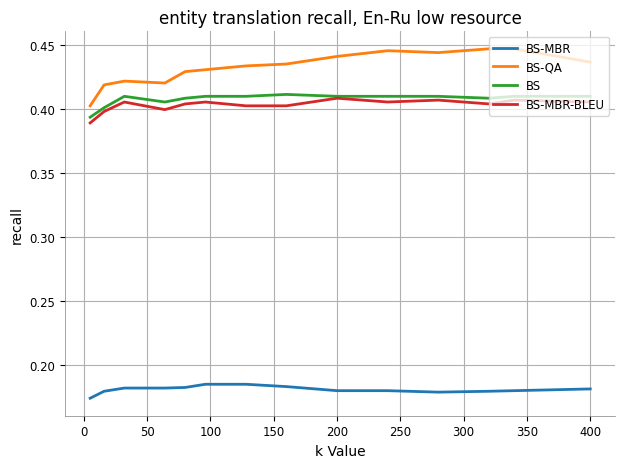

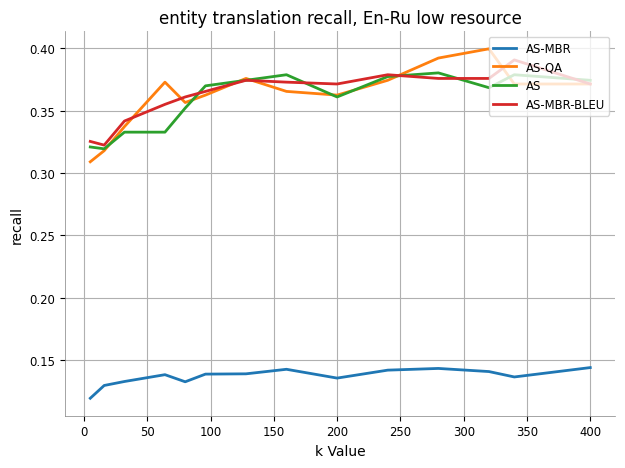

In [5]:
#entity accuracy
bs_mbr_entity_accuracy = []
bs_mbr_bleu_entity_accuracy = []
as_mbr_entity_accuracy = []
as_mbr_bleu_entity_accuracy = []
bs_qe_entity_accuracy = []
as_qe_entity_accuracy = []
bs_entity_accuracy = []
as_entity_accuracy = []
for k in k_list:
    bs_mbr_entity_accuracy.append(bs_mbr_metrics[k][0]["entity Accuracy"])
    bs_mbr_bleu_entity_accuracy.append(bs_mbr_bleu_metrics[k][0]["entity Accuracy"])
    bs_qe_entity_accuracy.append(bs_qe_metrics[k][0]["entity Accuracy"])
    bs_entity_accuracy.append(bs_metrics[k][0]["entity Accuracy"])
    as_mbr_entity_accuracy.append(as_mbr_metrics[k][0]["entity Accuracy"])
    as_mbr_bleu_entity_accuracy.append(as_mbr_bleu_metrics[k][0]["entity Accuracy"])
    as_qe_entity_accuracy.append(as_qe_metrics[k][0]["entity Accuracy"])
    as_entity_accuracy.append(as_metrics[k][0]["entity Accuracy"])
plt.figure()
plt.plot(k_list,bs_mbr_entity_accuracy,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_entity_accuracy,label="BS-QA",linewidth=2)
plt.plot(k_list,bs_entity_accuracy,label="BS",linewidth=2)
plt.plot(k_list,bs_mbr_bleu_entity_accuracy,label="BS-MBR-BLEU",linewidth=2)
plt.title('entity translation recall, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('recall')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,as_mbr_entity_accuracy,label="AS-MBR",linewidth=2)
plt.plot(k_list,as_qe_entity_accuracy,label="AS-QA",linewidth=2)
plt.plot(k_list,as_entity_accuracy,label="AS",linewidth=2)
plt.plot(k_list,as_mbr_bleu_entity_accuracy,label="AS-MBR-BLEU",linewidth=2)
plt.title('entity translation recall, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('recall')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()


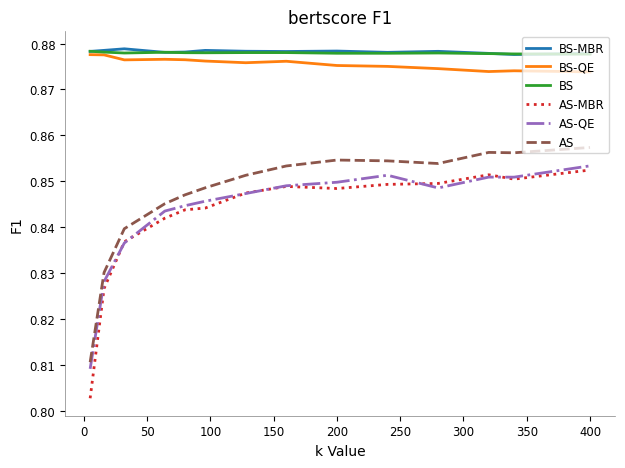

In [17]:
#bertscore F1
bs_mbr_bertscore_f1 = []
as_mbr_bertscore_f1 = []
bs_qe_bertscore_f1 = []
as_qe_bertscore_f1 = []
bs_bertscore_f1 = []
as_bertscore_f1 = []
for k in k_list:
    bs_mbr_bertscore_f1.append(bs_mbr_metrics[k][0]["bertscore F1"])
    bs_qe_bertscore_f1.append(bs_qe_metrics[k][0]["bertscore F1"])
    bs_bertscore_f1.append(bs_metrics[k][0]["bertscore F1"])
    as_mbr_bertscore_f1.append(as_mbr_metrics[k][0]["bertscore F1"])
    as_qe_bertscore_f1.append(as_qe_metrics[k][0]["bertscore F1"])
    as_bertscore_f1.append(as_metrics[k][0]["bertscore F1"])
plt.figure()
plt.plot(k_list,bs_mbr_bertscore_f1,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_bertscore_f1,label="BS-QE",linewidth=2)
plt.plot(k_list,bs_bertscore_f1,label="BS",linewidth=2)
plt.plot(k_list,as_mbr_bertscore_f1,label="AS-MBR",linewidth=2,linestyle=':')
plt.plot(k_list,as_qe_bertscore_f1,label="AS-QE",linewidth=2,linestyle='-.')
plt.plot(k_list,as_bertscore_f1,label="AS",linewidth=2,linestyle='--')
plt.title('bertscore F1')
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('F1')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(False)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()

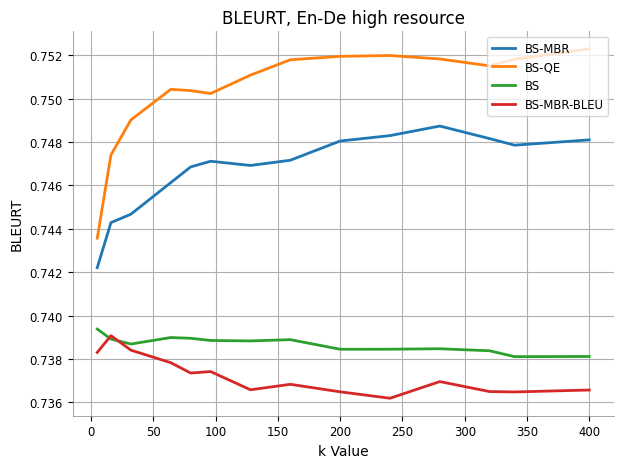

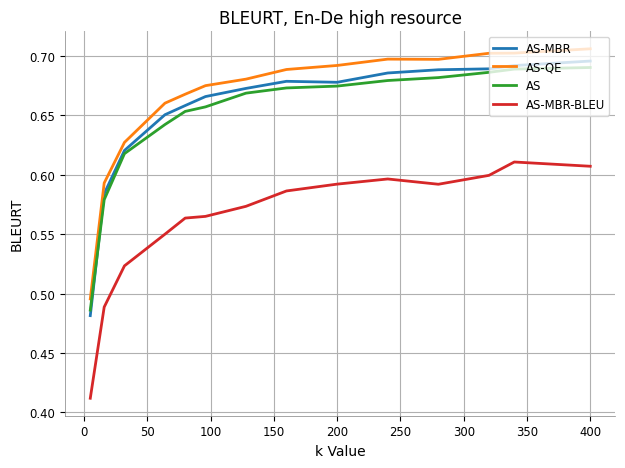

In [19]:
#BLEURT
bs_mbr_bleurt = []
bs_mbr_bleu_bleurt = []
as_mbr_bleurt = []
as_mbr_bleu_bleurt = []
bs_qe_bleurt = []
as_qe_bleurt = []
bs_bleurt = []
as_bleurt = []
for k in k_list:
    bs_mbr_bleurt.append(bs_mbr_metrics[k][0]["BLEURT"])
    bs_mbr_bleu_bleurt.append(bs_mbr_bleu_metrics[k][0]["BLEURT"])
    bs_qe_bleurt.append(bs_qe_metrics[k][0]["BLEURT"])
    bs_bleurt.append(bs_metrics[k][0]["BLEURT"])
    as_mbr_bleurt.append(as_mbr_metrics[k][0]["BLEURT"])
    as_mbr_bleu_bleurt.append(as_mbr_bleu_metrics[k][0]["BLEURT"])
    as_qe_bleurt.append(as_qe_metrics[k][0]["BLEURT"])
    as_bleurt.append(as_metrics[k][0]["BLEURT"])
plt.figure()
plt.plot(k_list,bs_mbr_bleurt,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_qe_bleurt,label="BS-QE",linewidth=2)
plt.plot(k_list,bs_bleurt,label="BS",linewidth=2)
plt.plot(k_list,bs_mbr_bleu_bleurt,label="BS-MBR-BLEU",linewidth=2)
plt.title('BLEURT, En-De high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('BLEURT')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,as_mbr_bleurt,label="AS-MBR",linewidth=2)
plt.plot(k_list,as_qe_bleurt,label="AS-QE",linewidth=2)
plt.plot(k_list,as_bleurt,label="AS",linewidth=2)
plt.plot(k_list,as_mbr_bleu_bleurt,label="AS-MBR-BLEU",linewidth=2)
plt.title('BLEURT, En-De high resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('BLEURT')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)
plt.show()

is in top3 hypothesis: 0.18659594985535197
is in top5 hypothesis: 0.26374156219864997
is in top10 hypothesis: 0.3958534233365477
is in top20 hypothesis: 0.5713596914175506
is in top50 hypothesis: 0.8114754098360656
is in top80 hypothesis: 0.9035679845708775


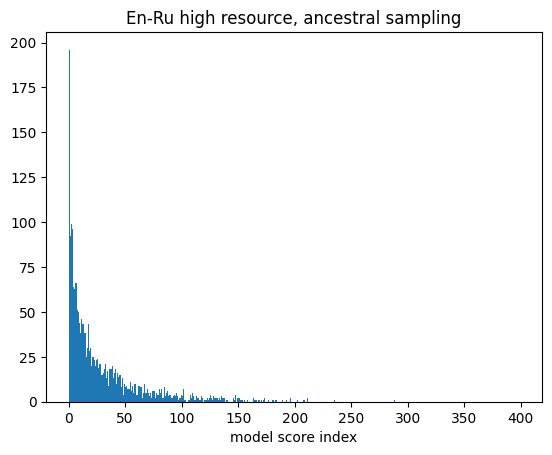

In [11]:
as_mbr_400=as_mbr_score[400]
as_qe_400=as_qe_score[400]
bs_mbr_400=bs_mbr_score[400]
bs_qe_400=bs_qe_score[400]
as_mbr_max_index=[]
as_qe_max_index=[]
bs_mbr_max_index=[]
bs_qe_max_index=[]
for group in range(len(as_mbr_400)//400):
    as_mbr_max_index.append(np.argmax(as_mbr_400[group*400:(group+1)*400]))
    as_qe_max_index.append(np.argmax(as_qe_400[group*400:(group+1)*400]))
    bs_mbr_max_index.append(np.argmax(bs_mbr_400[group*400:(group+1)*400]))
    bs_qe_max_index.append(np.argmax(bs_qe_400[group*400:(group+1)*400]))
#画出最大值的分布图
#以1为间隔
plt.figure()
plt.hist(as_mbr_max_index,bins=range(0,400,1),label="AS-MBR")
plt.title('En-Ru high resource, ancestral sampling')  # 添加图表标题
plt.xlabel('model score index')  # 添加 x 轴标签

print("is in top3 hypothesis:",len([x for x in as_mbr_max_index if x<=2])/len(as_mbr_max_index))
print("is in top5 hypothesis:",len([x for x in as_mbr_max_index if x<=4])/len(as_mbr_max_index))
print("is in top10 hypothesis:",len([x for x in as_mbr_max_index if x<=9])/len(as_mbr_max_index))
print("is in top20 hypothesis:",len([x for x in as_mbr_max_index if x<=19])/len(as_mbr_max_index))
print("is in top50 hypothesis:",len([x for x in as_mbr_max_index if x<=49])/len(as_mbr_max_index))
print("is in top80 hypothesis:",len([x for x in as_mbr_max_index if x<=79])/len(as_mbr_max_index))



is in top3 hypothesis: 0.08871745419479267
is in top5 hypothesis: 0.12005785920925748
is in top10 hypothesis: 0.17309546769527484
is in top20 hypothesis: 0.23143683702989393
is in top50 hypothesis: 0.35342333654773384
is in top80 hypothesis: 0.44021215043394407
is in top200 hypothesis: 0.6793635486981678


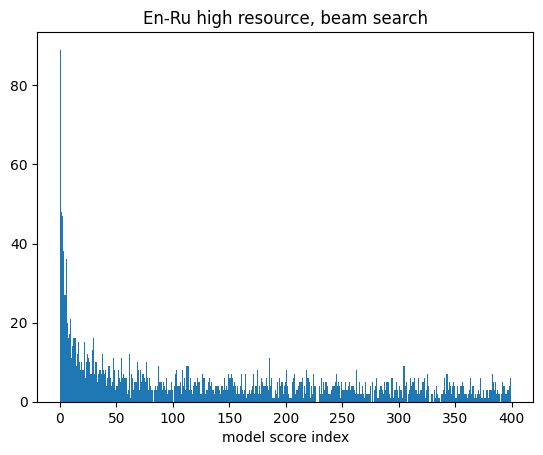

In [13]:
plt.figure()
plt.hist(bs_mbr_max_index,bins=range(0,400,1),label="BS-MBR")
plt.title('En-Ru high resource, beam search')  # 添加图表标题
plt.xlabel('model score index')  # 添加 x 轴标签
print("is in top3 hypothesis:",len([x for x in bs_mbr_max_index if x<=2])/len(bs_mbr_max_index))
print("is in top5 hypothesis:",len([x for x in bs_mbr_max_index if x<=4])/len(bs_mbr_max_index))
print("is in top10 hypothesis:",len([x for x in bs_mbr_max_index if x<=9])/len(bs_mbr_max_index))
print("is in top20 hypothesis:",len([x for x in bs_mbr_max_index if x<=19])/len(bs_mbr_max_index))
print("is in top50 hypothesis:",len([x for x in bs_mbr_max_index if x<=49])/len(bs_mbr_max_index))
print("is in top80 hypothesis:",len([x for x in bs_mbr_max_index if x<=79])/len(bs_mbr_max_index))
print("is in top200 hypothesis:",len([x for x in bs_mbr_max_index if x<=199])/len(bs_mbr_max_index))

is in top3 hypothesis: 0.5056417489421721
is in top5 hypothesis: 0.6198871650211566
is in top10 hypothesis: 0.7637517630465445
is in top20 hypothesis: 0.8674188998589563
is in top50 hypothesis: 0.9548660084626234
is in top80 hypothesis: 0.9816643159379408


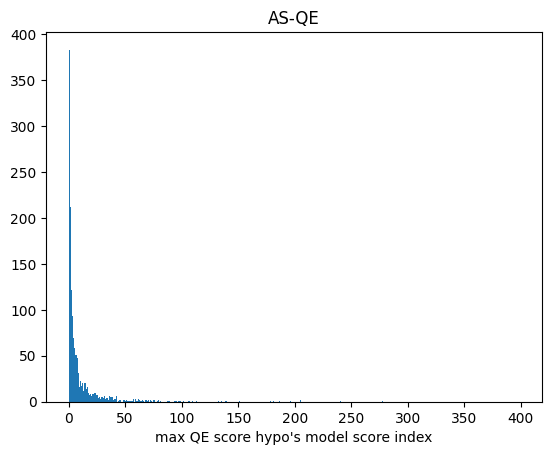

In [13]:
plt.figure()
plt.hist(as_qe_max_index,bins=range(0,400,1),label="AS-QE")
plt.title('AS-QE')
plt.xlabel('max QE score hypo\'s model score index')  # 添加 x 轴标签
print("is in top3 hypothesis:",len([x for x in as_qe_max_index if x<=2])/len(as_qe_max_index))
print("is in top5 hypothesis:",len([x for x in as_qe_max_index if x<=4])/len(as_qe_max_index))
print("is in top10 hypothesis:",len([x for x in as_qe_max_index if x<=9])/len(as_qe_max_index))
print("is in top20 hypothesis:",len([x for x in as_qe_max_index if x<=19])/len(as_qe_max_index))
print("is in top50 hypothesis:",len([x for x in as_qe_max_index if x<=49])/len(as_qe_max_index))
print("is in top80 hypothesis:",len([x for x in as_qe_max_index if x<=79])/len(as_qe_max_index))

In [8]:
import sentencepiece as spm
sp = spm.SentencePieceProcessor(model_file='/raid/lyu/fairseq-ru/baseline/spm_joint.model')
bs_output_tok={}
bs_mbr_output_tok={}
as_output_tok={}
as_mbr_output_tok={}
bs_qe_output_tok={}
as_qe_output_tok={}
bs_mbr_bleu_tok={}
as_mbr_bleu_tok={}
for k in tqdm(k_list):
    bs_mbr_output_tok[k]=sp.encode(bs_output_text_bs[k], out_type=str)
    bs_output_tok[k]=sp.encode(bs_output_text_bs[k], out_type=str)
    as_mbr_output_tok[k]=sp.encode(as_output_text_bs[k], out_type=str)
    as_output_tok[k]=sp.encode(as_output_text_bs[k], out_type=str)
    bs_qe_output_tok[k]=sp.encode(bs_output_text_qe[k], out_type=str)
    as_qe_output_tok[k]=sp.encode(as_output_text_qe[k], out_type=str)
    bs_mbr_bleu_tok[k]=sp.encode(bs_output_text_mbr_bleu[k], out_type=str)
    as_mbr_bleu_tok[k]=sp.encode(as_output_text_mbr_bleu[k], out_type=str)

100%|██████████| 14/14 [00:07<00:00,  1.90it/s]


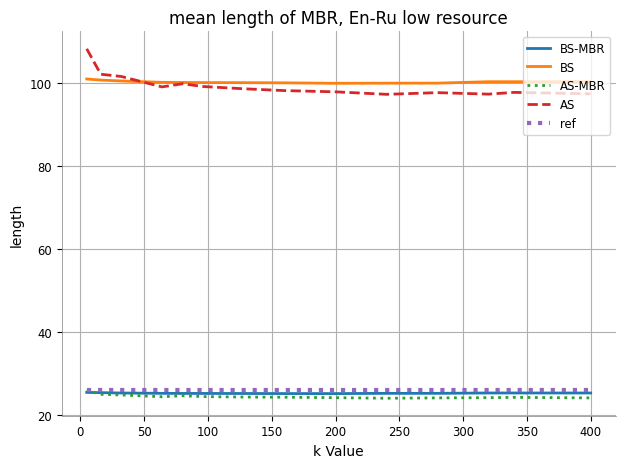

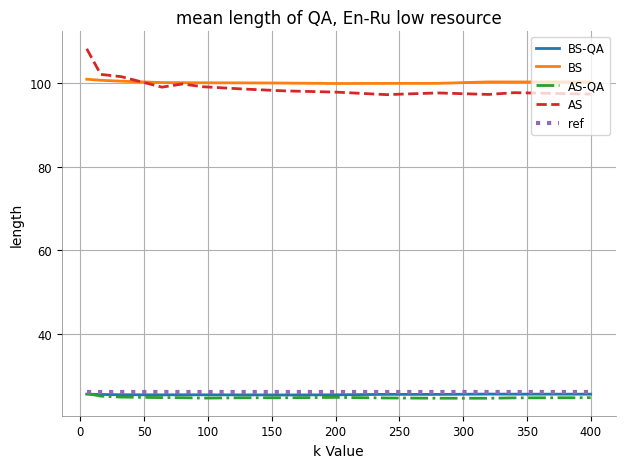

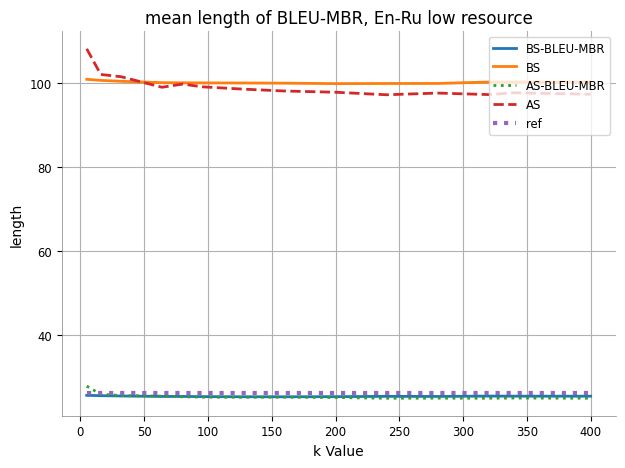

In [10]:
#统计tokenze后的长度分布
bs_mean_len_mbr = []
bs_mean_len_qe = []
bs_mean_len_bs = []
bs_mean_len_mbr_bleu = []
for k in k_list:
    bs_mean_len_mbr.append(np.mean([len(line) for line in bs_output_tok[k]]))
    bs_mean_len_qe.append(np.mean([len(line) for line in bs_qe_output_tok[k]]))
    bs_mean_len_bs.append(np.mean([len(line) for line in bs_output_text_bs[k]]))
    bs_mean_len_mbr_bleu.append(np.mean([len(line) for line in bs_mbr_bleu_tok[k]]))
as_mean_len_mbr = []
as_mean_len_qe = []
as_mean_len_bs = []
as_mean_len_mbr_bleu = []
for k in k_list:
    as_mean_len_mbr.append(np.mean([len(line) for line in as_output_tok[k]]))
    as_mean_len_qe.append(np.mean([len(line) for line in as_qe_output_tok[k]]))
    as_mean_len_bs.append(np.mean([len(line) for line in as_output_text_bs[k]]))
    as_mean_len_mbr_bleu.append(np.mean([len(line) for line in as_mbr_bleu_tok[k]]))
    
ref_len=[]   
with open(ref_file,"r",encoding="utf-8") as f:
    ref_text = [line.strip() for line in f.readlines()]
    ref_text=sp.encode(ref_text, out_type=str)
ref_mean_len = np.mean([len(line) for line in ref_text])
#画出长度分布的折线图
plt.figure()
plt.plot(k_list,bs_mean_len_mbr,label="BS-MBR",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_mbr,label="AS-MBR",linewidth=2,linestyle=':')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of MBR, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
plt.figure()
plt.plot(k_list,bs_mean_len_qe,label="BS-QA",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_qe,label="AS-QA",linewidth=2,linestyle='-.')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of QA, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域

# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

plt.show()
#再画一张mbr_bleu的图,放在旁边
plt.figure()
plt.plot(k_list,bs_mean_len_mbr_bleu,label="BS-BLEU-MBR",linewidth=2)
plt.plot(k_list,bs_mean_len_bs,label="BS",linewidth=2)
plt.plot(k_list,as_mean_len_mbr_bleu,label="AS-BLEU-MBR",linewidth=2,linestyle=':')
plt.plot(k_list,as_mean_len_bs,label="AS",linewidth=2,linestyle='--')
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linewidth=3,linestyle=':')
plt.title('mean length of BLEU-MBR, En-Ru low resource')  # 添加图表标题
plt.xlabel('k Value')  # 添加 x 轴标签
plt.ylabel('length')  # 添加 y 轴标签
plt.legend(loc='upper right', fontsize='small')  # 设置图例位置和大小
plt.grid(True)  # 添加网格线
plt.tight_layout()  # 自动调整子图参数,使之填充整个图像区域
# 可以设置刻度大小和可见性
plt.xticks(size = 'small')
plt.yticks(size = 'small')

# 优化边框颜色和粗细
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_color('grey')
ax.spines['left'].set_linewidth(0.5)

